# ЛР4


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

orders = pd.read_csv('olist_orders_dataset.csv', on_bad_lines='skip')
items = pd.read_csv('olist_order_items_dataset.csv', on_bad_lines='skip')

print('orders:', orders.shape)
print('items: ', items.shape)
orders.head()

orders: (192970, 8)
items:  (217684, 7)


/tmp/ipykernel_3799/4268774672.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv('olist_order_items_dataset.csv', on_bad_lines='skip')


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 1.1 типизация дат и индекс по времени

In [ ]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print('типы столбцов с датами:')
print(orders[date_cols].dtypes)

типы столбцов с датами:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [ ]:
orders_indexed = orders.set_index('order_purchase_timestamp').sort_index()
orders_indexed.head()

,order_id,customer_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_purchase_timestamp,,,,,,,
2016-09-04 21:15:19,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-10-07 13:18:03,2016-10-18 13:14:51,NaT,2016-10-20
2016-09-05 00:15:34,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-10-07 13:17:15,NaT,NaT,2016-10-28
2016-09-13 15:24:19,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-10-07 13:16:46,NaT,NaT,2016-09-30
2016-09-13 15:24:19,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-10-07 13:16:46,NaT,NaT,2016-09-30
2016-09-15 12:16:38,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04


### 1.2 время доставки в рабочих днях


In [ ]:
mask = orders['order_approved_at'].notna() & orders['order_delivered_customer_date'].notna()

approved = orders.loc[mask, 'order_approved_at'].values.astype('datetime64[D]')
delivered = orders.loc[mask, 'order_delivered_customer_date'].values.astype('datetime64[D]')

orders['delivery_time_working_days'] = np.nan
orders.loc[mask, 'delivery_time_working_days'] = np.busday_count(approved, delivered)

print('статистика срока доставки в рабочих днях:')
print(orders['delivery_time_working_days'].describe().round(2))

neg = (orders['delivery_time_working_days'] < 0).sum()
print('\nзаписей с отрицательным сроком:', int(neg))

статистика срока доставки в рабочих днях:
count    187177.00
mean          8.49
std           6.80
min          -5.00
25%           4.00
50%           7.00
75%          11.00
max         148.00
Name: delivery_time_working_days, dtype: float64

записей с отрицательным сроком: 67


In [ ]:
orders[['order_approved_at', 'order_delivered_customer_date', 'delivery_time_working_days']].head()

,order_approved_at,order_delivered_customer_date,delivery_time_working_days
0,2017-10-02 11:07:15,2017-10-10 21:25:13,6.0
1,2018-07-26 03:24:27,2018-08-07 15:27:45,8.0
2,2018-08-08 08:55:23,2018-08-17 18:06:29,7.0
3,2017-11-18 19:45:59,2017-12-02 00:28:42,10.0
4,2018-02-13 22:20:29,2018-02-16 18:17:02,3.0


### 1.3 SLA Breach (анализ просрочек)

In [ ]:
delivered_orders = orders.dropna(subset=['order_delivered_customer_date']).copy()

delivered_orders['is_delayed'] = (
    delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date']
)

print('всего доставленных заказов:', len(delivered_orders))
print('доля просроченных заказов: {:.1%}'.format(delivered_orders['is_delayed'].mean()))

всего доставленных заказов: 187206
доля просроченных заказов: 8.1%


In [ ]:
by_month = delivered_orders.groupby(
    delivered_orders['order_purchase_timestamp'].dt.to_period('M')
).agg(delayed_share=('is_delayed', 'mean'),
      orders=('is_delayed', 'size'))

big_months = by_month[by_month['orders'] >= 100]
worst_month = big_months['delayed_share'].idxmax()

print('худший месяц по доле просрочек:', worst_month,
      '({:.1%})'.format(big_months.loc[worst_month, 'delayed_share']))
print()
big_months.round(3)

худший месяц по доле просрочек: 2018-03 (21.4%)



,delayed_share,orders
order_purchase_timestamp,,
2016-10,0.011,525
2017-01,0.031,1443
2017-02,0.031,3207
2017-03,0.055,4927
2017-04,0.078,4479
2017-05,0.036,6884
2017-06,0.039,6099
2017-07,0.035,7527
2017-08,0.033,8126


### 2.1 непрерывная сетка дней и дневная выручка

In [ ]:
items_dated = items.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id', how='left'
)
daily_revenue = items_dated.groupby(
    items_dated['order_purchase_timestamp'].dt.normalize()
)['price'].sum()
daily_revenue.index.name = 'date'

print('дней, в которые были продажи:', len(daily_revenue))
daily_revenue.head()

дней, в которые были продажи: 616


,price
date,
2016-09-04,145.78
2016-09-05,119.00
2016-09-15,539.88
2016-10-02,400.00
2016-10-03,1853.92


In [ ]:
start_date = daily_revenue.index.min()
end_date = daily_revenue.index.max()
print('период данных:', start_date.date(), '->', end_date.date())

full_grid = pd.date_range(start=start_date, end=end_date, freq='D')

daily_full = daily_revenue.reindex(full_grid)
print('всего дней в сетке:', len(full_grid))
print('из них дней без продаж (NaN):', int(daily_full.isna().sum()))

daily_full = daily_full.fillna(0)
daily_full.index.name = 'date'
daily_full.head()

период данных: 2016-09-04 -> 2018-09-03
всего дней в сетке: 730
из них дней без продаж (NaN): 114


,price
date,
2016-09-04,145.78
2016-09-05,119.00
2016-09-06,0.00
2016-09-07,0.00
2016-09-08,0.00


In [ ]:
print('выручка за последние дни доступных данных:')
print(daily_full.tail(12).round(0))

revenue = daily_full['2017-01-01':'2018-08-22']
print('\nядро для анализа:', revenue.index.min().date(), '->', revenue.index.max().date(),
      '|', len(revenue), 'дней подряд')

выручка за последние дни доступных данных:
date
2018-08-23    59259.0
2018-08-24    37052.0
2018-08-25    39700.0
2018-08-26    29973.0
2018-08-27    19804.0
2018-08-28    13734.0
2018-08-29     5285.0
2018-08-30        0.0
2018-08-31        0.0
2018-09-01        0.0
2018-09-02        0.0
2018-09-03      580.0
Freq: D, Name: price, dtype: float64

ядро для анализа: 2017-01-01 -> 2018-08-22 | 599 дней подряд


### 2.2 пиковые часы по дням недели

In [ ]:
orders['weekday'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour'] = orders['order_purchase_timestamp'].dt.hour

hour_pivot = orders.pivot_table(
    index='weekday', columns='hour', values='order_id', aggfunc='count'
)

week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_pivot = hour_pivot.reindex(week_order)

peak_hour = hour_pivot.idxmax(axis=1)

print('час пик продаж по дням недели:')
for day in week_order:
    print('{:10s} -> {:02d}:00'.format(day, int(peak_hour[day])))

час пик продаж по дням недели:
Monday     -> 21:00
Tuesday    -> 14:00
Wednesday  -> 11:00
Thursday   -> 16:00
Friday     -> 13:00
Saturday   -> 19:00
Sunday     -> 20:00



### 3.1 накопительная выручка с начала года (YTD)

In [ ]:
ts = revenue.to_frame('revenue')

ts['ytd_revenue'] = (
    ts.groupby(ts.index.year)['revenue']
      .expanding().sum()
      .reset_index(level=0, drop=True)
)
ts[['revenue', 'ytd_revenue']].head()

,revenue,ytd_revenue
date,,
2017-01-01,0.0,0.0
2017-01-02,0.0,0.0
2017-01-03,0.0,0.0
2017-01-04,0.0,0.0
2017-01-05,1485.7,1485.7


In [ ]:
print('YTD на 2017-12-31:    ', round(ts.loc['2017-12-31', 'ytd_revenue'], 2))
print('сумма выручки за 2017:', round(ts.loc['2017', 'revenue'].sum(), 2))

YTD на 2017-12-31:     23104937.74
сумма выручки за 2017: 23104937.74


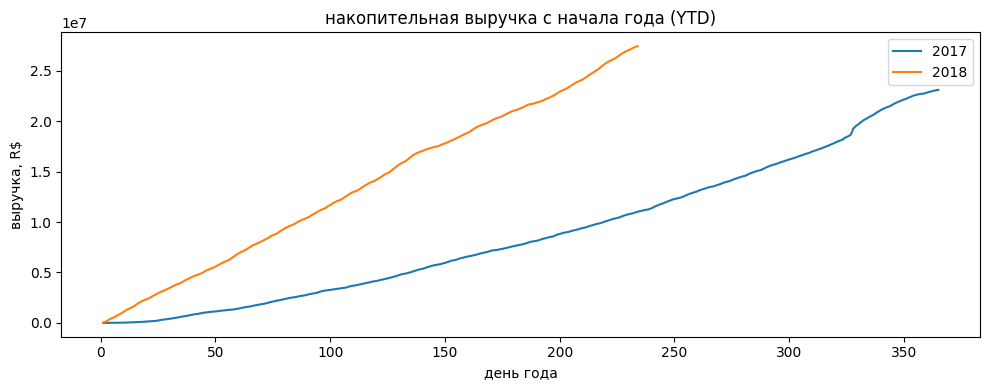

In [ ]:
plt.figure(figsize=(10, 4))
for year in [2017, 2018]:
    part = ts[ts.index.year == year]
    plt.plot(part.index.dayofyear, part['ytd_revenue'], label=str(year))
plt.title('накопительная выручка с начала года (YTD)')
plt.xlabel('день года')
plt.ylabel('выручка, R$')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 скользящий Z-score и локальные аномалии
**динамический** порог на 30-дневном окне:

$$Z_t = \frac{X_t - \mu_{t-30}}{\sigma_{t-30}}$$

где $\mu_{t-30}$ и $\sigma_{t-30}$ это скользящие среднее и стандартное отклонение за 30 дней. аномальными всплесками считаем дни, где $Z_t > 3$.

In [ ]:
ts['roll_mean_30'] = ts['revenue'].rolling(window=30).mean()
ts['roll_std_30'] = ts['revenue'].rolling(window=30).std()

ts['z_score'] = (ts['revenue'] - ts['roll_mean_30']) / ts['roll_std_30']

anomalies = ts[ts['z_score'] > 3]
print('найдено аномальных дней (Z > 3):', len(anomalies))
anomalies[['revenue', 'roll_mean_30', 'z_score']].round(2)

найдено аномальных дней (Z > 3): 4


,revenue,roll_mean_30,z_score
date,,,
2017-08-29,123349.44,67669.95,3.12
2017-11-20,163402.40,85588.10,4.04
2017-11-23,171688.05,90574.31,3.13
2017-11-24,575073.62,107530.37,5.09


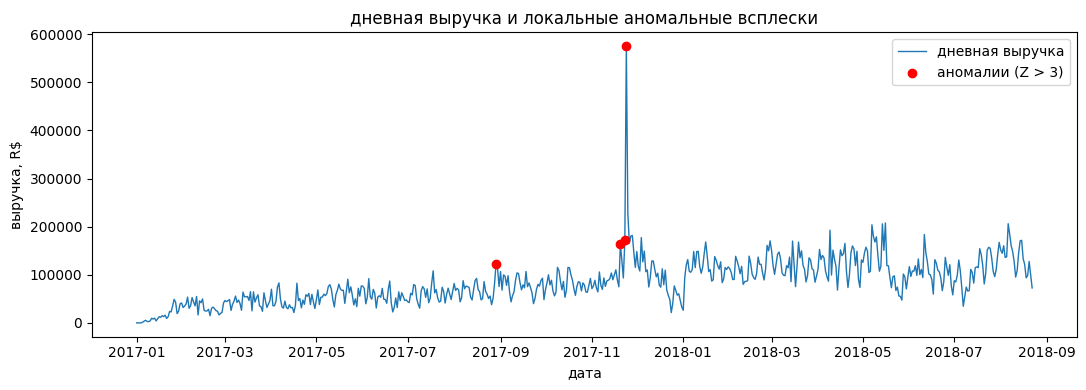

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(ts.index, ts['revenue'], linewidth=1, label='дневная выручка')
plt.scatter(anomalies.index, anomalies['revenue'], color='red', zorder=5, label='аномалии (Z > 3)')
plt.title('дневная выручка и локальные аномальные всплески')
plt.xlabel('дата')
plt.ylabel('выручка, R$')
plt.legend()
plt.tight_layout()
plt.show()


### 4.1 безопасное окно `revenue_last_7d`

комбинируем `.shift(1)` и `.rolling(7)`: после сдвига окно из 7 элементов суммирует строго дни $t-7 \dots t-1$.

In [ ]:
ts['revenue_last_7d'] = ts['revenue'].shift(1).rolling(window=7).sum()
ts[['revenue', 'revenue_last_7d']].head(10)

,revenue,revenue_last_7d
date,,
2017-01-01,0.00,NaN
2017-01-02,0.00,NaN
2017-01-03,0.00,NaN
2017-01-04,0.00,NaN
2017-01-05,1485.70,NaN
2017-01-06,3665.52,NaN
2017-01-07,5407.60,NaN
2017-01-08,2838.32,10558.82
2017-01-09,2695.16,13397.14


In [ ]:
day = '2018-03-15'
prev_7_days = ts.loc['2018-03-08':'2018-03-14', 'revenue']

print('revenue_last_7d за', day, '=', round(ts.loc[day, 'revenue_last_7d'], 2))
print('ручная сумма выручки за 7 дней до него =', round(prev_7_days.sum(), 2))
print('выручка самого', day, '=', round(ts.loc[day, 'revenue'], 2), '— в сумму не входит')

revenue_last_7d за 2018-03-15 = 756575.82
ручная сумма выручки за 7 дней до него = 756575.82
выручка самого 2018-03-15 = 170047.86 — в сумму не входит


### 4.2 темп неделя-к-неделе (WoW Growth)
сравниваем выручку за последние 7 дней (`revenue_last_7d`) с выручкой за такой же период неделей ранее (`revenue_prev_7d`). последнюю получаем сдвигом `revenue_last_7d` ещё на 7 дней.

In [ ]:
ts['revenue_prev_7d'] = ts['revenue_last_7d'].shift(7)

ts['wow_growth'] = ts['revenue_last_7d'] / ts['revenue_prev_7d'] - 1

top_drops = ts.dropna(subset=['wow_growth']).nsmallest(3, 'wow_growth')
print('топ-3 дня с самым сильным падением выручки неделя-к-неделе:')
top_drops[['revenue_last_7d', 'revenue_prev_7d', 'wow_growth']].round(2)

топ-3 дня с самым сильным падением выручки неделя-к-неделе:


,revenue_last_7d,revenue_prev_7d,wow_growth
date,,,
2018-05-28,493926.60,969939.58,-0.49
2018-05-27,519691.07,1014437.61,-0.49
2018-05-26,559249.83,1027127.97,-0.46
